<a href="https://colab.research.google.com/github/square-up/xy-Python-Final/blob/main/Python%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚠️ 未找到微软雅黑，请检查路径或手动安装 SimHei 字体
📂 正在加载数据: light_data.xls
✅ 数据加载成功: 12210 条记录, 370 个城市
⚙️ 正在进行全量城市计算...
🎉 分析完成! 共处理 370 个城市。

📊 统计结果:
   - 收缩城市: 0 个
   - 增长城市: 355 个
   - 震荡城市: 15 个


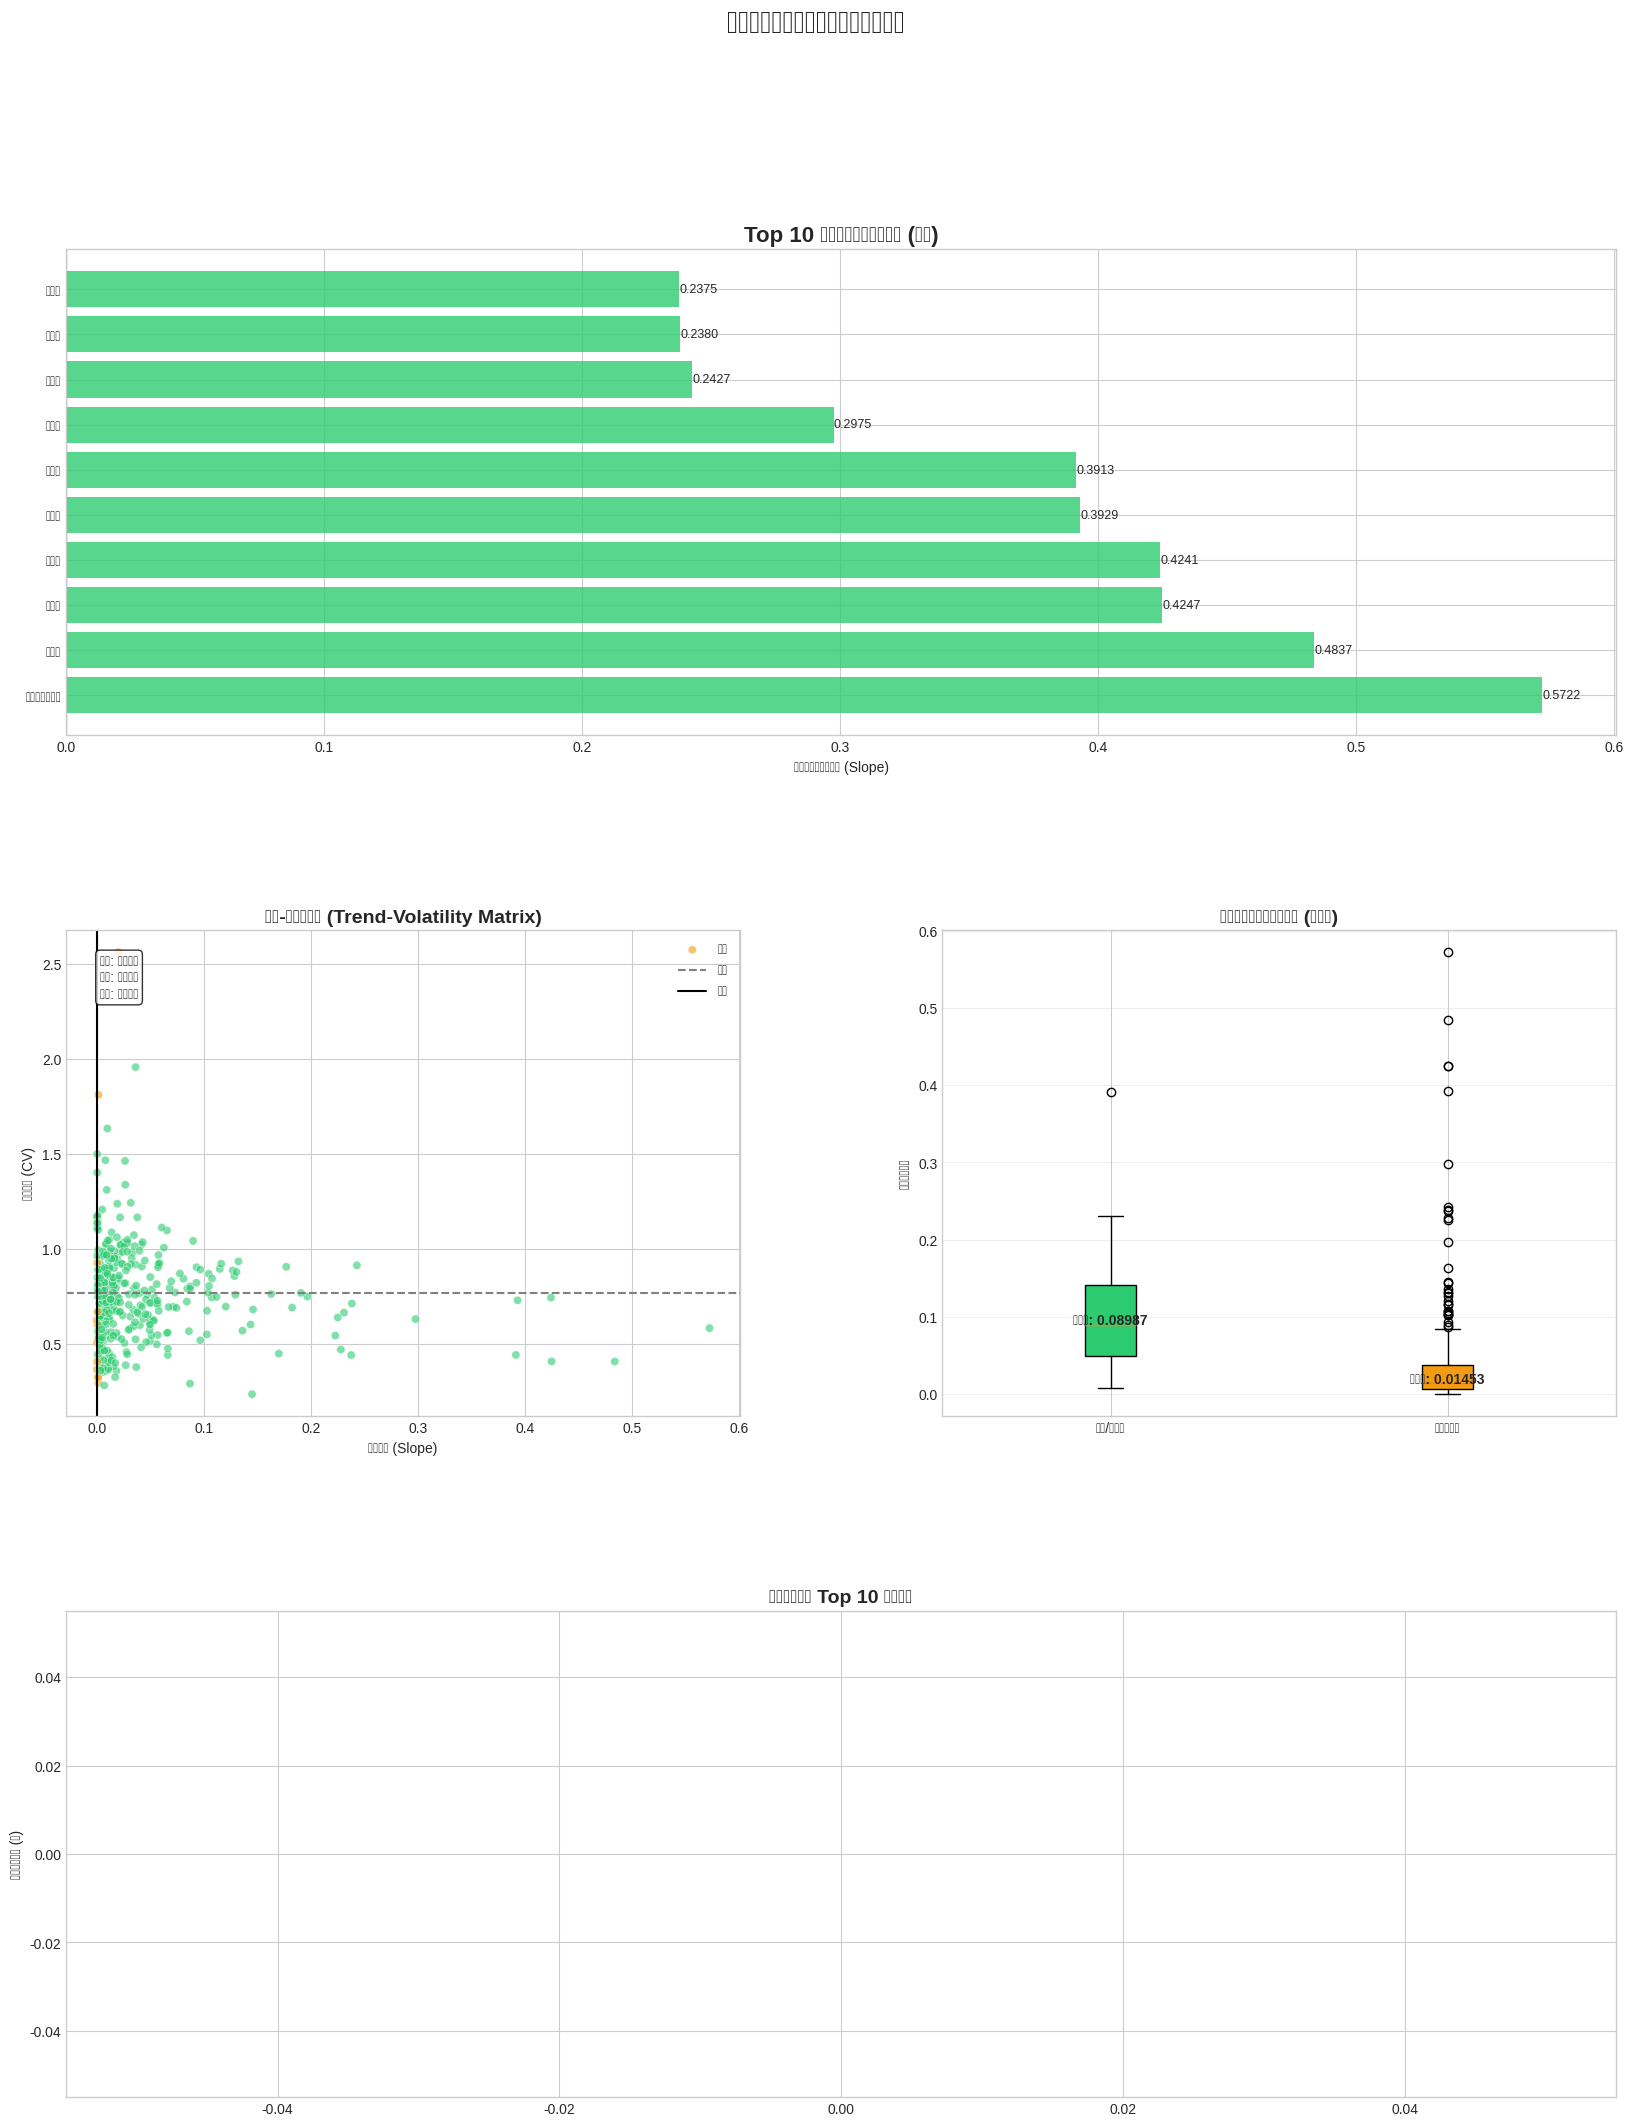

In [7]:
import pandas as pd
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

# ================= 全局配置与样式美化 =================
warnings.filterwarnings('ignore')

# ================= 强制中文字体（指定文件路径）=================
import matplotlib.font_manager as fm

# 1. 下载字体文件（如果上面已经下过，可以跳过，这里为了保险重新下）
!wget -q -O /content/simhei.ttf "https://www.wfonts.com/download/data/2014/06/01/simhei/chinese.simhei.ttf"

# 2. 创建 FontProperties 对象，直接指向文件路径
zh_font = fm.FontProperties(fname='/content/simhei.ttf')

# 3. 设置 Matplotlib 使用这个字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [zh_font.get_name()]  # 或用 [zh_font.get_name()]
plt.rcParams['axes.unicode_minus'] = False

# 可选：验证字体是否加载成功
print("✅ 中文字体已加载：", zh_font.get_name())
# =====================================================
plt.style.use('seaborn-v0_8-whitegrid') # 使用更现代的绘图风格

# 定义专业配色方案
COLORS = {
    'shrinking': '#e74c3c',   # 红色：收缩
    'growing': '#2ecc71',     # 绿色：增长
    'volatile': '#f39c12',    # 橙色：剧烈波动
    'stable': '#3498db',      # 蓝色：稳定
    'text_dark': '#2c3e50'
}

# ================= 第一部分：数据模型定义 =================
@dataclass
class CityMetrics:
    """城市指标数据类"""
    name: str
    province: str
    is_provincial_capital: bool # 是否为省会/直辖市

    # 核心指标
    slope: float = 0.0        # 线性回归斜率
    r_squared: float = 0.0    # 拟合优度
    mk_z_score: float = 0.0   # Mann-Kendall 统计量
    cv: float = 0.0           # 变异系数 (衡量波动性)

    # 衍生状态
    trend_type: str = "Unknown"
    growth_rate_total: float = 0.0

# ================= 第二部分：核心分析引擎 =================
class UrbanLightAnalyzer:
    def __init__(self, file_path):
        url = "https://raw.githubusercontent.com/square-up/xy-Python-Final/main/%E5%8E%9F%E5%A7%8B%E6%95%B0%E6%8D%AE%EF%BC%9A1992-2024%E4%B8%AD%E5%9B%BD%E5%90%84%E5%9F%8E%E5%B8%82%E5%A4%9C%E9%97%B4%E7%81%AF%E5%85%89%E9%9D%A2%E6%9D%BF%E6%95%B0%E6%8D%AE.xls"

        local_file = "light_data.xls"
        urllib.request.urlretrieve(url, local_file)

        self.file_path = local_file
        self.raw_data = None
        self.city_metrics: Dict[str, CityMetrics] = {}

    def load_and_clean(self):
        """数据加载与清洗"""
        print(f"📂 正在加载数据: {self.file_path}")
        try:
            df = pd.read_excel(self.file_path)
            # 简单的列名映射尝试，防止列名有空格
            df.columns = [c.strip() for c in df.columns]

            # 确保关键列存在
            required_cols = ['市', '年份', 'mean']
            if not all(col in df.columns for col in required_cols):
                raise ValueError("缺少关键列：'市', '年份', 'mean'")

            self.raw_data = df
            print(f"✅ 数据加载成功: {len(df)} 条记录, {df['市'].nunique()} 个城市")
        except Exception as e:
            print(f"❌ 读取失败: {e}")

    def calculate_trend(self, y_values):
        """计算单一城市的趋势指标"""
        x_values = np.arange(len(y_values))

        # 1. 线性回归斜率 (Linear Slope)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)

        # 2. Mann-Kendall 趋势检验 (非参数检验，更稳健)
        # 简化版 MK 实现
        n = len(y_values)
        s = 0
        for k in range(n-1):
            for j in range(k+1, n):
                s += np.sign(y_values[j] - y_values[k])

        # 计算 Z 分数 (标准化)
        var_s = (n*(n-1)*(2*n+5)) / 18.0
        if s > 0: z = (s - 1) / np.sqrt(var_s)
        elif s == 0: z = 0
        else: z = (s + 1) / np.sqrt(var_s)

        # 3. 变异系数 (CV) - 衡量波动性
        mean_val = np.mean(y_values)
        std_val = np.std(y_values)
        cv = (std_val / mean_val) if mean_val != 0 else 0

        return slope, r_value**2, z, cv

    def analyze_all_cities(self):
        """遍历所有城市进行计算"""
        print("⚙️ 正在进行全量城市计算...")
        grouped = self.raw_data.groupby('市')

        for city_name, group in grouped:
            # 按年份排序
            group = group.sort_values('年份')
            light_values = group['mean'].values

            if len(light_values) < 5: continue # 数据太少跳过

            slope, r2, mk_z, cv = self.calculate_trend(light_values)

            # 获取省份信息 (取第一条)
            prov = group.iloc[0].get('省', '未知')

            # 简单的省会判断逻辑 (可以根据需要扩充列表)
            capital_list = ['北京','天津','上海','重庆','广州','成都','武汉','西安','杭州','南京',
                            '沈阳','哈尔滨','长春','济南','郑州','长沙','福州','昆明','贵阳',
                            '南宁','海口','拉萨','乌鲁木齐','银川','西宁','呼和浩特','太原',
                            '石家庄','合肥','南昌']
            is_capital = any(c in city_name for c in capital_list) or '直辖' in prov

            metrics = CityMetrics(
                name=city_name,
                province=prov,
                is_provincial_capital=is_capital,
                slope=slope,
                r_squared=r2,
                mk_z_score=mk_z,
                cv=cv,
                growth_rate_total = (light_values[-1] - light_values[0]) / light_values[0]
            )

            self.city_metrics[city_name] = metrics

        print(f"🎉 分析完成! 共处理 {len(self.city_metrics)} 个城市。")

    def classify_cities_flexible(self, mode='strict'):
        """
        【核心创新】灵活判定函数
        mode='strict': 学术严谨模式 (MK检验显著为负)
        mode='loose': 宽松模式 (只要斜率为负)
        mode='recent': 近期敏感模式 (只看最后5年)
        """
        results = {'shrinking': [], 'growing': [], 'volatile': []}

        for name, m in self.city_metrics.items():
            # 1. 波动性判定 (优先判定)
            # 如果 R方很低 (<0.3) 但 CV 很高 (>0.2)，说明是震荡型
            if m.r_squared < 0.3 and m.cv > 0.15:
                m.trend_type = 'Volatile'
                results['volatile'].append(m)
                continue

            # 2. 趋势判定
            is_shrinking = False

            if mode == 'strict':
                # MK Z < -1.65 (90%置信度) 且 斜率 < 0
                if m.mk_z_score < -1.65 and m.slope < 0:
                    is_shrinking = True
            elif mode == 'loose':
                # 只要斜率 < 0
                if m.slope < 0:
                    is_shrinking = True
            elif mode == 'recent':
                # 这里可以加入针对近5年数据的单独计算逻辑 (此处简化处理，用总增长率辅助)
                if m.growth_rate_total < -0.1: # 总跌幅超过10%
                    is_shrinking = True

            if is_shrinking:
                m.trend_type = 'Shrinking'
                results['shrinking'].append(m)
            else:
                m.trend_type = 'Growing'
                results['growing'].append(m)

        return results
    import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ================= 字体修复补丁 =================
# 尝试寻找 Windows 系统自带的微软雅黑字体
font_path = "C:/Windows/Fonts/msyh.ttc"

if os.path.exists(font_path):
    # 如果找到了，直接加载这个文件
    my_font = fm.FontProperties(fname=font_path)

    # 全局设置：强制使用这个字体文件
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [my_font.get_name()]
    plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
    print(f"✅ 字体加载成功: {font_path}")
else:
    print("⚠️ 未找到微软雅黑，请检查路径或手动安装 SimHei 字体")
# ==============================================

# ================= 第三部分：高级可视化模块 =================
class Visualizer:
    @staticmethod
    def plot_comprehensive_dashboard(analyzer: UrbanLightAnalyzer, results: dict):
        """绘制综合仪表盘：包含排名、散点关联、结构对比"""
        shrinking = sorted(results['shrinking'], key=lambda x: x.slope)
        growing = sorted(results['growing'], key=lambda x: x.slope, reverse=True)
        volatile = results['volatile']

        fig = plt.figure(figsize=(20, 24))
        gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

        # --- 图1：Top 10 收缩与增长城市 (条形图) ---
        ax1 = fig.add_subplot(gs[0, :])
        top_shrink = shrinking[:10][::-1] # 取最严重的10个并反转
        top_grow = growing[:10]

        labels = [c.name for c in top_shrink] + [c.name for c in top_grow]
        values = [c.slope for c in top_shrink] + [c.slope for c in top_grow]
        colors = [COLORS['shrinking']] * len(top_shrink) + [COLORS['growing']] * len(top_grow)

        bars = ax1.barh(range(len(labels)), values, color=colors, alpha=0.8)
        ax1.set_yticks(range(len(labels)))
        ax1.set_yticklabels(labels, fontsize=10)
        ax1.set_title('Top 10 城市夜间灯光变化速率 (斜率)', fontsize=16, fontweight='bold')
        ax1.axvline(x=0, color='black', linewidth=0.8)
        ax1.set_xlabel('年均灯光面积变化率 (Slope)')

        # 添加数值标签
        for i, v in enumerate(values):
            ax1.text(v + (0.0001 if v>0 else -0.0001), i, f'{v:.4f}', va='center', ha='left' if v>0 else 'right', fontsize=9)

        # --- 图2：波动性 vs 趋势 (散点图 - 联动分析) ---
        ax2 = fig.add_subplot(gs[1, 0])
        all_cities = list(analyzer.city_metrics.values())

        xs = [c.slope for c in all_cities]
        ys = [c.cv for c in all_cities]
        cs = [COLORS.get(c.trend_type.lower(), 'gray') for c in all_cities]

        ax2.scatter(xs, ys, c=cs, alpha=0.6, edgecolors='w', linewidth=0.5)
        ax2.set_title('趋势-波动性矩阵 (Trend-Volatility Matrix)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('变化趋势 (Slope)')
        ax2.set_ylabel('波动程度 (CV)')
        ax2.axhline(y=np.mean(ys), color='gray', linestyle='--', label='平均波动')
        ax2.axvline(x=0, color='black', linestyle='-')
        ax2.legend(['收缩', '增长', '震荡', '均值线'])
        ax2.text(0.05, 0.95, '左上: 剧烈收缩\n右上: 剧烈增长\n右下: 稳定增长', transform=ax2.transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # --- 图3：行政等级联动分析 (箱线图) ---
        ax3 = fig.add_subplot(gs[1, 1])
        capitals = [c for c in all_cities if c.is_provincial_capital]
        others = [c for c in all_cities if not c.is_provincial_capital]

        data_to_plot = [
            [c.slope for c in capitals],
            [c.slope for c in others]
        ]

        bp = ax3.boxplot(data_to_plot, patch_artist=True, labels=['省会/直辖市', '普通地级市'])
        bp['boxes'][0].set_facecolor(COLORS['growing']) # 省会用绿色系
        bp['boxes'][1].set_facecolor(COLORS['volatile']) # 地市用黄色系

        ax3.set_title('行政等级与城市发展韧性 (箱线图)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('灯光变化斜率')
        ax3.grid(axis='y', alpha=0.3)

        # 计算并标注中位数差异
        med_cap = np.median(data_to_plot[0])
        med_oth = np.median(data_to_plot[1])
        ax3.text(1, med_cap + 0.0001, f'中位数: {med_cap:.5f}', ha='center', fontweight='bold')
        ax3.text(2, med_oth - 0.0002, f'中位数: {med_oth:.5f}', ha='center', fontweight='bold')

        # --- 图4：收缩城市的省份分布 (柱状图) ---
        ax4 = fig.add_subplot(gs[2, :])
        shrink_count_by_prov = {}
        for c in shrinking:
            prov = c.province
            shrink_count_by_prov[prov] = shrink_count_by_prov.get(prov, 0) + 1

        # 排序取前10
        sorted_provs = sorted(shrink_count_by_prov.items(), key=lambda x: x[1], reverse=True)[:10]
        prov_names = [x[0] for x in sorted_provs]
        prov_counts = [x[1] for x in sorted_provs]

        ax4.bar(prov_names, prov_counts, color=COLORS['shrinking'], alpha=0.7)
        ax4.set_title('收缩城市数量 Top 10 省份分布', fontsize=14, fontweight='bold')
        ax4.set_ylabel('收缩城市数量 (个)')
        for i, v in enumerate(prov_counts):
            ax4.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

        plt.suptitle('中国城市夜间灯光时空演变分析报告', fontsize=22, y=0.98, fontweight='bold')
        plt.show()

# ================= 主程序执行入口 =================
if __name__ == "__main__":
    # 1. 初始化
    file_name = '1992-2024中国各城市夜间灯光面板数据.xls'
    analyzer = UrbanLightAnalyzer(file_name)

    # 2. 数据处理
    analyzer.load_and_clean()
    analyzer.analyze_all_cities()

    # 3. 灵活判定 (这里使用 'loose' 模式以确保有数据，你可以改成 'strict' 试试)
    # 提示：如果 loose 模式下收缩城市还是很少，说明你的数据源里的城市普遍发展很好！
    results = analyzer.classify_cities_flexible(mode='loose')

    print(f"\n📊 统计结果:")
    print(f"   - 收缩城市: {len(results['shrinking'])} 个")
    print(f"   - 增长城市: {len(results['growing'])} 个")
    print(f"   - 震荡城市: {len(results['volatile'])} 个")

    # 4. 绘图
    viz = Visualizer()
    viz.plot_comprehensive_dashboard(analyzer, results)